In [1]:
import os
from os.path import dirname

root_dir = dirname(os.getcwd())
os.chdir(root_dir)

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.nn import *
from src.utils import *

In [3]:
data_name = "kaggle"

In [4]:
# Load the training dataset for testing
with open(f'data/vehicle_data_{data_name}_test.pkl', 'rb') as f:
    test_dataset = pickle.load(f)

print(f"Loaded dataset with {test_dataset['data'].shape[0]} samples")
print(f"Data shape: {test_dataset['data'].shape}")
print(f"Unique labels: {torch.unique(test_dataset['label']).tolist()}")

Loaded dataset with 72 samples
Data shape: torch.Size([72, 3, 50])
Unique labels: [0, 1]


In [5]:
# Create dataloader from the evaluation dataset
eval_dataloader = get_dataloader(test_dataset)

In [6]:
nn_model = NeuralNetwork()
nn_state = torch.load(f'models/{data_name}/nn/averaged_model/best_model.pth')
nn_model.load_state_dict(nn_state)
nn_model.eval()

NeuralNetwork(
  (hidden_activation): ReLU()
  (final_activation): Softmax(dim=-1)
  (fc1): Linear(in_features=150, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [7]:
cnn_model = ConvolutionalNeuralNetwork()
cnn_state = torch.load(f'models/{data_name}/cnn/averaged_model/best_model.pth')
cnn_model.load_state_dict(cnn_state)
cnn_model.eval()

ConvolutionalNeuralNetwork(
  (conv1): Conv1d(3, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
  (hidden_activation): ReLU()
  (final_activation): Softmax(dim=-1)
)

In [8]:
nn_true_label = []
nn_pred_label = []

with torch.no_grad():
    for inputs, labels in eval_dataloader:
        outputs = nn_model(inputs)
        _, predicted = torch.max(outputs, 1)

        nn_true_label.extend(labels.cpu().numpy())
        nn_pred_label.extend(predicted.cpu().numpy())

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Class names for better readability
class_names = ['Bike', 'Car']

In [10]:
# Neural Network Classification Report
print("="*60)
print("NEURAL NETWORK - Classification Report")
print("="*60)
print(classification_report(nn_true_label, nn_pred_label, target_names=class_names, digits=4))
print()

NEURAL NETWORK - Classification Report
              precision    recall  f1-score   support

        Bike     0.7097    0.7586    0.7333        29
         Car     0.8293    0.7907    0.8095        43

    accuracy                         0.7778        72
   macro avg     0.7695    0.7747    0.7714        72
weighted avg     0.7811    0.7778    0.7788        72




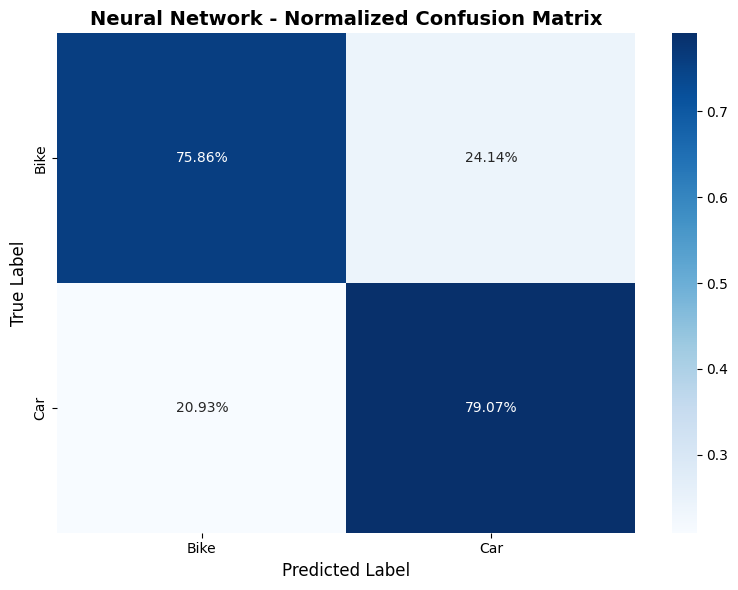

In [11]:
# Neural Network Confusion Matrix (Normalized)
nn_cm = confusion_matrix(nn_true_label, nn_pred_label, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(nn_cm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.title('Neural Network - Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
cnn_true_label = []
cnn_pred_label = []

with torch.no_grad():
    for inputs, labels in eval_dataloader:
        outputs = cnn_model(inputs)
        _, predicted = torch.max(outputs, 1)

        cnn_true_label.extend(labels.cpu().numpy())
        cnn_pred_label.extend(predicted.cpu().numpy())

In [13]:
# CNN Classification Report
print("="*60)
print("CONVOLUTIONAL NEURAL NETWORK - Classification Report")
print("="*60)
print(classification_report(cnn_true_label, cnn_pred_label, target_names=class_names, digits=4))
print()

CONVOLUTIONAL NEURAL NETWORK - Classification Report
              precision    recall  f1-score   support

        Bike     0.7500    0.9310    0.8308        29
         Car     0.9444    0.7907    0.8608        43

    accuracy                         0.8472        72
   macro avg     0.8472    0.8609    0.8458        72
weighted avg     0.8661    0.8472    0.8487        72




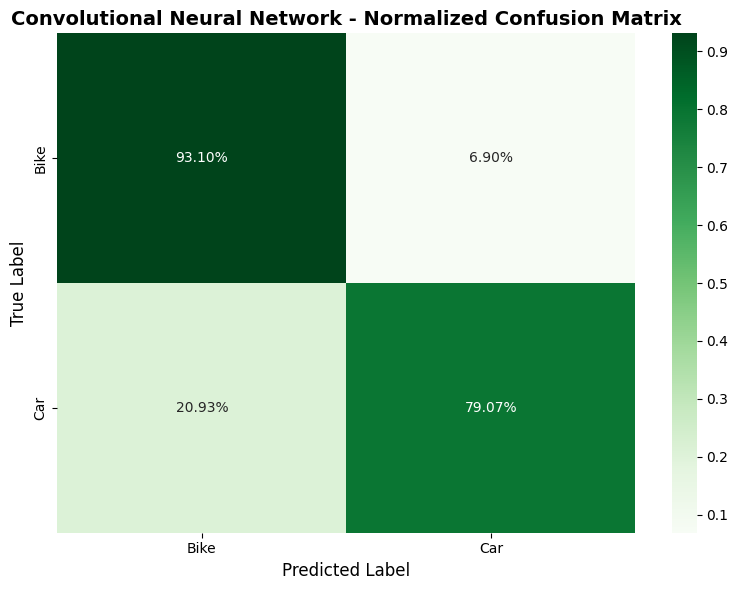

In [14]:
# CNN Confusion Matrix (Normalized)
cnn_cm = confusion_matrix(cnn_true_label, cnn_pred_label, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cnn_cm, annot=True, fmt='.2%', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.title('Convolutional Neural Network - Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()